In [8]:
# Load required packages
required_packages = ["LinearAlgebra","Statistics", "MAT","Random","LIBSVM", "LIBSVMdata", "Plots","Zygote", "Measures", "PyPlot","Arpack"]
for pkg in required_packages
    try
        eval(Meta.parse("using $pkg"))
    catch e
        @warn "$pkg not found, installing..."
        import Pkg
        Pkg.add(pkg)
        eval(Meta.parse("using $pkg"))
    end
end

In [9]:
#______________________________________________________________________________#
#             After switching to "Julia" kernel, run this cell                 #
#______________________________________________________________________________#
using LinearAlgebra
using Statistics
using MAT,LIBSVMdata, LIBSVM
using Random
using Plots
using Zygote
using Measures
using PyPlot
using Arpack
#______________________________________________________________________________#

#_________________________________setting problem______________________________#
#                --- Lasso Problem Data: Logistic Regression Problem ---                   #
#______________________________________________________________________________#
# Set random seed for reproducibility
Random.seed!(23)
tau = 50
# Function to parse LIBSVM format from a file
using LIBSVMdata
 A, y = load_dataset("a1a",
     dense   = false,
     replace = false,
     verbose = true,
 )
 m = size(A, 1)
n = size(A, 2)
# Regularization parameter
omega = 1/m  # Common choice; adjust as needed

# Define regularized logistic loss function:
# f(x) = (1/m) * sum(log(1 + exp(-y_i * a_i^T x))) + omega * ||x||_2^2
f(x) = mean(log.(1 .+ exp.(-y .* (A * x)))) + omega * norm(x, 2)^2
# Gradient via automatic differentiation
grad_f(x) = Zygote.gradient(f, x)[1]

# Lipschitz constant estimation
# Lipschitz constant estimation
# For (1/m)*sum(log(1+exp(-y_i*a_i^T x))): L_logistic = ||A||^2 / (4m)
# For omega*||x||_2^2: L_reg = 2*omega
# Total: L = ||A||^2/(4m) + 2*omega
L = opnorm(Matrix(A))^2 / (4 * m) + 2 * omega
println("Lipschitz constant (L): $L")

# Initial point (sparse vector)

x0 = zeros(n,1)

# Linear Minimization Oracle (LMO)
rho = 1  # radius of ball
# Linear Minimization Oracle (LMO) unit l_2 ball
function lmo(g; rho=1)
    norm_g = norm(g, 2)
    return norm_g > 0 ? -rho * g / norm_g : zeros(length(g))
end
#
max_iter = 3000

# Save data to .mat file
# # Define output directory
# output_dir = "/content/output"
# mkpath(output_dir)  # Create directory if it doesn't exist
# matwrite(joinpath(output_dir, "data.mat"), Dict(
#     "m" => n,
#     "n" => n,
#     "A" => Matrix(A),
#     "x0" => x0,
#     "L" => L,
#     "max_iter" => max_iter
# ))

# println("Saved: ", joinpath(output_dir, "data.mat"))
#______________________________________________________________________________#

0.0%┣                                             ┫ 0/1.6k [00:00<00:00, -0s/it]
100.0%┣█████████████████████████████████████┫ 1.6k/1.6k [00:00<00:00, 66.4kit/s]
100.0%┣█████████████████████████████████████┫ 1.6k/1.6k [00:00<00:00, 65.6kit/s]


The data a1a was already downloaded
Loading the dataset...
Lipschitz constant (L): 1.5684036239643369


3000

In [10]:
# Ensure all necessary packages are loaded
#using LinearAlgebra
#using Statistics
#using MAT
#using Random
#using Plots
#using Zygote
#using Measures
#using PyPlot
#using CSV
#using Arpack
#using LIBSVM
#______________________________________________________________________________#
#__________________________________Main Functions______________________________#
#______________________________________________________________________________#

#___________ __FW: Adaptive step-size with constant scalling___________________#
function conditional_gradient_adaptive(f, grad_f, lmo, x0, rho, max_iter, gamma; epsilon=1e-5, delta=1e-10, beta=2)
    println("\e[34m________Adaptive step-size: with constant scaling_________")
    x_prev = copy(x0)
    x_curr = copy(x0)
    values = [f(x_curr)]
    times = [0.0]
    gaps = Float64[]
    L_ks = Float64[]
    steps = Float64[]
    backtrack_counts = Int[]
    k = 0
    prev_grad = grad_f(x_prev)
    current_f = f(x_curr)
    prev_t_k = 0.0  # Initialize previous step size for k=0
    while k < max_iter
        start = time()
        current_grad = grad_f(x_curr)
        v = lmo(current_grad)
        grad_norm = norm(current_grad)
        if grad_norm <= epsilon
            println(">>>       Terminated at k=$k, Dual Gap: $(round(grad_norm, digits=4))")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, grad_norm)
            break
        end
        if k == 0
            Random.seed!(23)
            d0 = randn(length(x0))
            L_k = gamma * ((norm(grad_f(x0) - grad_f(x0 + 1e-3 * d0)) / (1e-3 * norm(d0))) + delta)
        else
            grad_diff = norm(current_grad - prev_grad)
            L_k = gamma * (grad_diff / (rho * prev_t_k) + delta)  # Updated L_k using previous t_{k-1}
        end
        t_k = grad_norm / (rho * L_k)
        i = 0
        while true
            x_new = x_curr + t_k * v
            new_f = f(x_new)
            if current_f - new_f >= rho * t_k * grad_norm - (L_k / 2) * t_k^2 * rho^2
                x_prev = copy(x_curr)
                x_curr = x_new
                push!(backtrack_counts, i)
                break
            else
                L_k *= beta
                t_k = grad_norm / (rho * L_k)
                i += 1
            end
        end
        iteration_time = time() - start
        k += 1
        current_f = f(x_curr)
        prev_grad = current_grad
        prev_t_k = t_k  # Store current t_k for use in next iteration
        push!(gaps, grad_norm)
        push!(steps, t_k)
        push!(values, current_f)
        push!(times, iteration_time)
        push!(L_ks, L_k)
        if k % 100 == 0   # Print progress only every 100 iterations
            println("k $k: Dual Gap = $(round(grad_norm, digits=4)), t_k = $(round(t_k, digits=6)), L_k = $(round(L_k, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(current_f, digits=6))")
        end
    end
    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), L_k = $(round(L_ks[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Adaptive Method (γ=$gamma):")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total backtracking steps: $(sum(backtrack_counts))")
    println("Total iterations: $k")
    println("Objective value: $(round(current_f, digits=6))")
    println("Max L_k: $(round(maximum(L_ks), digits=6))")
    println("Mean L_k: $(round(mean(L_ks), digits=6))")
    println("____________________________________________________________\e[0m")
    return (x_curr, values, times, gaps, L_ks, backtrack_counts, steps)
end
#______________________________________________________________________________#
#____________FW: Adaptive step-size with adjustable scalling___________________#
function conditional_gradient_adjustable_scaling(f, grad_f, lmo, x0, rho, max_iter, gamma; epsilon=1e-5, delta=1e-10, beta=2)
    println("\e[33m_____________________Adaptive step-size with adjustable scalling_____________________")
    x_prev = copy(x0)
    x_curr = copy(x0)
    values = [f(x_curr)]
    times = [0.0]
    gaps = Float64[]
    L_ks = Float64[]
    steps = Float64[]
    backtrack_counts = Int[]
    gamma_history = [gamma]  # Track gamma over iterations
    k = 0
    prev_grad = grad_f(x_prev)
    current_f = f(x_curr)
    recent_backtracks = Int[]  # Store backtracking counts for the last 10 iterations
    prev_t_k = 0.0  # Initialize previous step size for k=0

    while k < max_iter
        start = time()
        current_grad = grad_f(x_curr)
        v = lmo(current_grad)
        grad_norm = norm(current_grad)
        if grad_norm <= epsilon
            println(">>>       Terminated at k=$k, Dual Gap: $(round(grad_norm, digits=4))")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, grad_norm)
            break
        end
        if k == 0
            Random.seed!(23)
            d0 = randn(length(x0))
            L_k = gamma * ((norm(grad_f(x0) - grad_f(x0 + 1e-3 * d0)) / (1e-3 * norm(d0))) + delta)
        else
            grad_diff = norm(current_grad - prev_grad)
            L_k = gamma * (grad_diff / (rho * prev_t_k) + delta)  # Updated L_k using previous t_{k-1}
        end
        t_k = grad_norm / (rho * L_k)
        i = 0
        while true
            x_new = x_curr + t_k * v
            new_f = f(x_new)
            if current_f - new_f >= rho * t_k * grad_norm - (L_k / 2) * t_k^2 * rho^2
                x_prev = copy(x_curr)
                x_curr = x_new
                push!(backtrack_counts, i)
                push!(recent_backtracks, i)
                break
            else
                L_k *= beta
                t_k = grad_norm / (rho * L_k)
                i += 1
            end
        end
        iteration_time = time() - start
        k += 1
        current_f = f(x_curr)
        prev_grad = current_grad
        prev_t_k = t_k  # Store current t_k for use in next iteration
        push!(gaps, grad_norm)
        push!(steps, t_k)
        push!(values, current_f)
        push!(times, iteration_time)
        push!(L_ks, L_k)

        # Adaptive gamma adjustment every 10 iterations
        if k % 10 == 0 && k > 0
            total_backtracks = sum(recent_backtracks)
            if total_backtracks == 0
                gamma = gamma * 0.9  # Decrease gamma, with a lower bound
            elseif total_backtracks > 10
                gamma = min(1, gamma * 1.1)  # Increase gamma, with an upper bound
            end
            push!(gamma_history, gamma)
            recent_backtracks = Int[]  # Reset for the next 10 iterations
        elseif k % 10 == 0
            push!(gamma_history, gamma)
            recent_backtracks = Int[]
        else
            push!(recent_backtracks, i)
        end

        if k % 100 == 0
            println("k $k: Dual Gap = $(round(grad_norm, digits=4)), t_k = $(round(t_k,

 digits=6)), L_k = $(round(L_k, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(current_f, digits=6))")
        end
    end
    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), L_k = $(round(L_ks[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Adaptive Method (final γ=$(round(gamma, digits=4))):")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total backtracking steps: $(sum(backtrack_counts))")
    println("Total iterations: $k")
    println("Objective value: $(round(current_f, digits=6))")
    println("Max L_k: $(round(maximum(L_ks), digits=6))")
    println("Mean L_k: $(round(mean(L_ks), digits=6))")
    println("____________________________________________________________\e[0m")
    return (x_curr, values, times, gaps, L_ks, backtrack_counts, steps, gamma_history)
end
#______________________________________________________________________________#
#___________________________FW: Pedregosa et al. step-size_____________________#
function conditional_gradient_Pedregosa(f, grad_f, lmo, x0, rho, max_iter; epsilon=1e-5)
    println("\e[31m_____________________Pedregosa et al. step-size_____________")
    x_prev = copy(x0)
    values = [f(x_prev)]
    times = [0.0]
    gaps = Float64[]
    L_ks = Float64[]
    steps = Float64[]
    backtrack_counts = Int[]
    k = 0
    tau = 2.0
    eta = 0.9
    Random.seed!(23)
    d0 = randn(length(x0))
    L_minus1 = norm(grad_f(x0) - grad_f(x0 + 1e-3 * d0)) / (1e-3 * norm(d0))
    M = L_minus1 * eta
    while k < max_iter
        start = time()
        grad = grad_f(x_prev)
        v = lmo(grad)
        grad_norm=norm(grad)
        f_prev = f(x_prev)
        if grad_norm <= epsilon
            println(">>>       Terminated at k=$k, Dual Gap: $(round(grad_norm, digits=4))")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, grad_norm)
            break
        end
        t_k = min(grad_norm / (M * rho), Inf)
        i = 0
        x_new = x_prev
        while true
            x_new = x_prev + t_k * v
            f_new = f(x_new)
            if f_prev - f_new >= rho * t_k * grad_norm - (M / 2) * t_k^2 * rho^2
                push!(backtrack_counts, i)
                break
            else
                M *= tau
                t_k = min(grad_norm / (M * rho), Inf)
                i += 1
            end
        end
        x_prev = x_new
        k += 1
        iteration_time = time() - start
        push!(values, f(x_new))
        push!(gaps, grad_norm)
        push!(times, iteration_time)
        push!(L_ks, M)
         push!(steps, t_k)
        if k % 100 == 0   # Print progress only every 100 iterations
            println("k $k: Dual Gap = $(round(grad_norm, digits=4)), t_k = $(round(t_k, digits=6)), M = $(round(M, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(f(x_new), digits=4))")
        end
        M = M * eta
    end
    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), L_k = $(round(L_ks[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Pedregosa Method:")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total backtracking steps: $(sum(backtrack_counts))")
    println("Total iterations: $k")
    println("Objective value: $(round(f(x_prev), digits=6))")
    println("Max L_k: $(round(maximum(L_ks), digits=4))")
    println("Mean L_k: $(round(mean(L_ks), digits=4))")
    println("____________________________________________________________\e[0m")
    return (x_prev, values, times, gaps, L_ks, backtrack_counts, steps)
end

#______________________________________________________________________________#
#AdaBB: Adaptive Barzilai-Borwein Algorithm#   1
function adabb(f, grad_f, x0, max_iter, alpha0; epsilon=1e-5)
    println("\e[33m____________________AdaBB_________________________")

    # Initialize
    x_prev = copy(x0)
    grad_prev = grad_f(x_prev)
    gap = norm(grad_prev)
    # First step: x^1 = x^0 - alpha_0 * grad f(x^0)
    x = x_prev - alpha0 * grad_prev

    # Compute lambda_1 to determine theta_0
    grad_curr = grad_f(x)
    s_1 = x - x_prev
    y_1 = grad_curr - grad_prev
    lambda_1 = dot(y_1, s_1) / dot(y_1, y_1)

    # Compute theta_0 based on lambda_1
    if lambda_1 >= sqrt(2) * alpha0
        theta0=min(lambda_1^2 / (2 * alpha0^2) - 1.0, 1e12)
    else
        theta0 = 0.0
    end

    alpha_km1 = alpha0      # alpha_{k-1}
    theta_km1 = theta0      # theta_{k-1}

    values = [f(x_prev), f(x)]
    times = [0.0]
    gaps = Float64[]
    steps = [alpha0]

    k = 1
    while k < max_iter
        start = time()

        # Reuse grad_curr from theta_0 computation on first iteration
        if k > 1
            grad_curr = grad_f(x)
        end
        if gap <= epsilon
            println(">>>       Terminated at k=$k, Dual Gap: $(round(gap, digits=4))")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, gap)
            break
        end
        # Compute differences
        s_k = x - x_prev               # x^k - x^{k-1}
        y_k = grad_curr - grad_prev    # grad f(x^k) - grad f(x^{k-1})

        # Compute lambda_k (BB step size)
        lambda_k = dot(y_k, s_k) / dot(y_k, y_k)

        # Adaptive step-size selection
        if lambda_k >= alpha_km1
            alpha_k = sqrt(1 + theta_km1) * alpha_km1
            theta_k = alpha_k / alpha_km1
        elseif alpha_km1 / 2 < lambda_k < alpha_km1
            # Case (i)
            alpha_k = lambda_k
            theta_k = 2 * alpha_k / alpha_km1 - alpha_k / lambda_k
        else
            # Case (iii)
            alpha_k = lambda_k / sqrt(2)
            theta_k = alpha_k / alpha_km1
        end

        # Update iterates
        x_prev = copy(x)
        grad_prev = copy(grad_curr)
        x = x - alpha_k * grad_curr
        k += 1
        # Update for next iteration
        alpha_km1 = alpha_k
        theta_km1 = theta_k

        iteration_time = time() - start
        # ============ END TIMED SECTION ============
        f_curr = f(x)
        gap = norm(grad_prev)
        push!(gaps, gap)
        push!(values, f_curr)
        push!(times, iteration_time)
        push!(steps, alpha_k)

        if k % 100 == 0
            println("k $k: Gap = $(round(gap, digits=6)), alpha_k = $(round(alpha_k, digits=8)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(f_curr, digits=6))")
        end
    end

    println("k $k: Gap = $(round(gaps[end], digits=6)), alpha_k = $(round(steps[end], digits=8)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("AdaBB Method:")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total iterations: $k")
    println("Objective value: $(round(f(x), digits=6))")
    println("____________________________________________________________\e[0m")

    return (x, values, times, gaps, steps)
end

adabb (generic function with 1 method)

In [11]:
# Ensure all necessary packages are loaded
using LinearAlgebra
using Statistics
using MAT
using Random
using Plots
using Zygote
using Measures
using PyPlot
using Arpack
#______________________________________________________________________________#
pyplot()
PyPlot.PyCall.pyimport("warnings").filterwarnings("ignore")
output_dir = "/content/output"  # Changed to distinguish from logistic output
mkpath(output_dir)
#____________________________________Run_______________________________________#
# --- Run and Plot (Adapted for Least_Squares_Radom) ---
results_our = conditional_gradient_adaptive(f, grad_f, lmo, x0, rho, max_iter, 1/4)
MAT.matwrite(joinpath(output_dir, "results_FW_OUR.mat"), Dict(
    "x" => results_our[1], "values" => results_our[2], "times" => results_our[3],
    "gaps" => results_our[4], "L_ks" => results_our[5], "backtrack_counts" => results_our[6],
    "steps" => results_our[7]
))
println("Saved: ", joinpath(output_dir, "results_FW_OUR.mat"))
#____________
results_our5 = conditional_gradient_adjustable_scaling(f, grad_f, lmo, x0, rho, max_iter, 1/4)
MAT.matwrite(joinpath(output_dir, "results_FW_OUR_5.mat"), Dict(
    "x" => results_our5[1], "values" => results_our5[2], "times" => results_our5[3],
    "gaps" => results_our5[4], "L_ks" => results_our5[5], "backtrack_counts" => results_our5[6],
    "steps" => results_our5[7]
))
println("Saved: ", joinpath(output_dir, "results_FW_OUR_5.mat"))
#____________
results_ped = conditional_gradient_Pedregosa(f, grad_f, lmo, x0, rho, max_iter)
MAT.matwrite(joinpath(output_dir, "results_FW_Pedregosa.mat"), Dict(
    "x" => results_ped[1], "values" => results_ped[2], "times" => results_ped[3],
    "gaps" => results_ped[4], "L_ks" => results_ped[5], "backtrack_counts" => results_ped[6],
    "steps" => results_ped[7]
))
println("Saved: ", joinpath(output_dir, "results_FW_Pedregosa.mat"))
#____________

________Adaptive step-size: with constant scaling_________
k 100: Dual Gap = 0.0011, t_k = 0.002588, L_k = 0.417611, Time = 0.0007 sec, f_k = 0.330071
k 200: Dual Gap = 0.0003, t_k = 0.000845, L_k = 0.330037, Time = 0.0006 sec, f_k = 0.329911
k 300: Dual Gap = 0.0002, t_k = 0.000184, L_k = 1.006018, Time = 0.0007 sec, f_k = 0.329899
>>>       Terminated at k=346, Dual Gap: 0.0
k 346: Dual Gap = 0.0, t_k = 4.4e-5, L_k = 0.75816, Time = 0.0003 sec, f_k = 0.329897
Adaptive Method (γ=0.25):
Total time: 0.4007 seconds
Total backtracking steps: 702
Total iterations: 346
Objective value: 0.329897
Max L_k: 2.209061
Mean L_k: 0.437997
____________________________________________________________
Saved: /content/output/results_FW_OUR.mat
_____________________Adaptive step-size with adjustable scalling_____________________
k 100: Dual Gap = 0.0032, t_k = 0.004342, L_k = 0.746035, Time = 0.0005 sec, f_k = 0.330428
k 200: Dual Gap = 0.0, t_k = 0.000605, L_k = 0.047472, Time = 0.0005 sec, f_k = 0.329

In [12]:
#____________________________________Run AdaBB_________________________________#

# Set initial step size
alpha0 = 10^(-10)

# Run AdaBB
results_adabb = adabb(f, grad_f, x0, max_iter, alpha0; epsilon=1e-5)

# Save results
output_dir = "/content/output"
mkpath(output_dir)

MAT.matwrite(joinpath(output_dir, "results_adabb.mat"), Dict(
    "x"      => results_adabb[1],
    "values" => results_adabb[2],
    "times"  => results_adabb[3],
    "gaps"   => results_adabb[4],
    "steps"  => results_adabb[5]
))
println("Saved: ", joinpath(output_dir, "results_adabb.mat"))

____________________AdaBB_________________________
k 100: Gap = 0.001984, alpha_k = 2.47777123, Time = 0.0002 sec, f_k = 0.330815
k 200: Gap = 0.000682, alpha_k = 20.13513233, Time = 0.0003 sec, f_k = 0.330024
k 300: Gap = 0.000309, alpha_k = 1.04309853, Time = 0.0002 sec, f_k = 0.329924
k 400: Gap = 0.000141, alpha_k = 3.75375722, Time = 0.0002 sec, f_k = 0.329903
k 500: Gap = 5.6e-5, alpha_k = 9.75877966, Time = 0.0003 sec, f_k = 0.329898
k 600: Gap = 2.2e-5, alpha_k = 6.62502638, Time = 0.0002 sec, f_k = 0.329897
>>>       Terminated at k=699, Dual Gap: 0.0
k 699: Gap = 1.0e-5, alpha_k = 15.19486843, Time = 0.0003 sec, f_k = 0.329897
AdaBB Method:
Total time: 0.1906 seconds
Total iterations: 699
Objective value: 0.329897
____________________________________________________________
Saved: /content/output/results_adabb.mat



# Summary of Results:

Method               Iterations    Time (s)   Objective     Gradient Norm
───────────────────  ──────────  ──────────  ───────────  ───────────
Adaptive constant           346         0.4       0.3299          0.0
Adaptive adjustable         224        0.15       0.3299          0.0
Pure backtracking          1167        0.64       0.3299          0.0
AdaBB                       699        0.19       0.3299          0.0

All computations and plotting complete. Check /content/output for results.
✅ Saved: R_Regression_a1a_L.eps


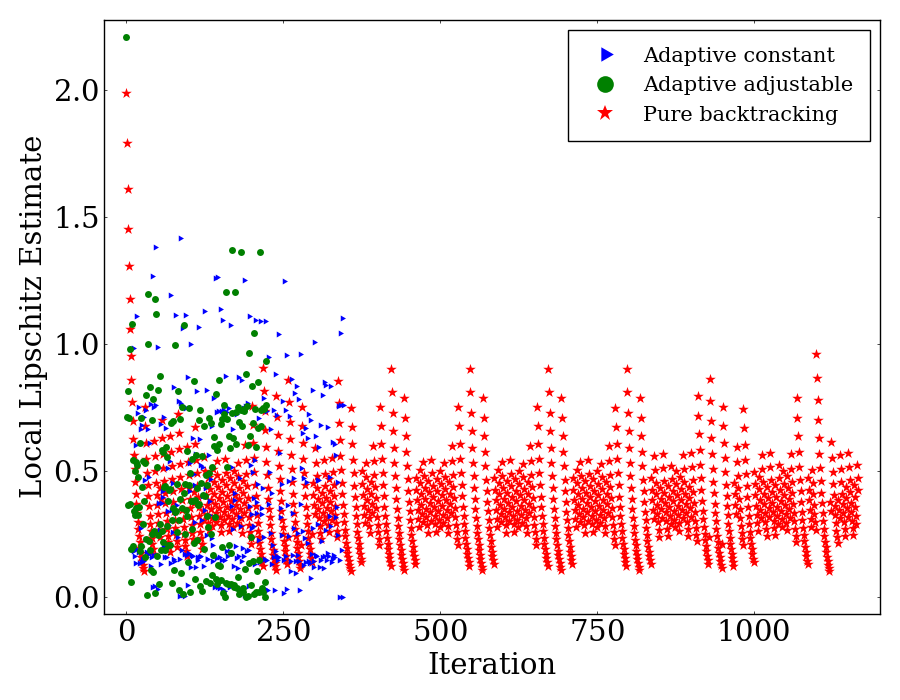

✅ Saved: R_Regression_a1a_Gap.eps


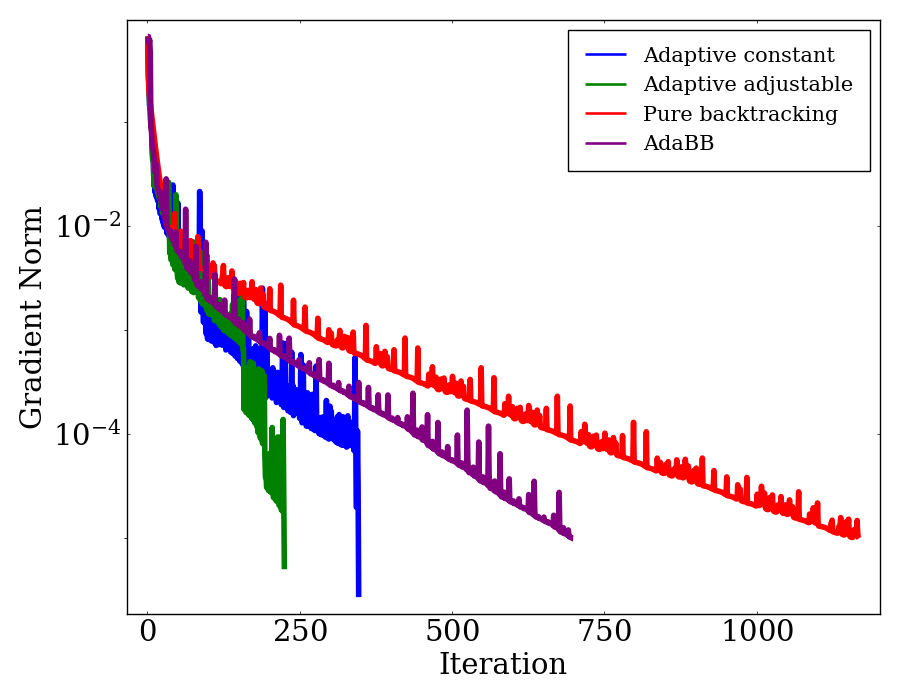

✅ Saved: R_Regression_a1a_Gap_vs_time.eps


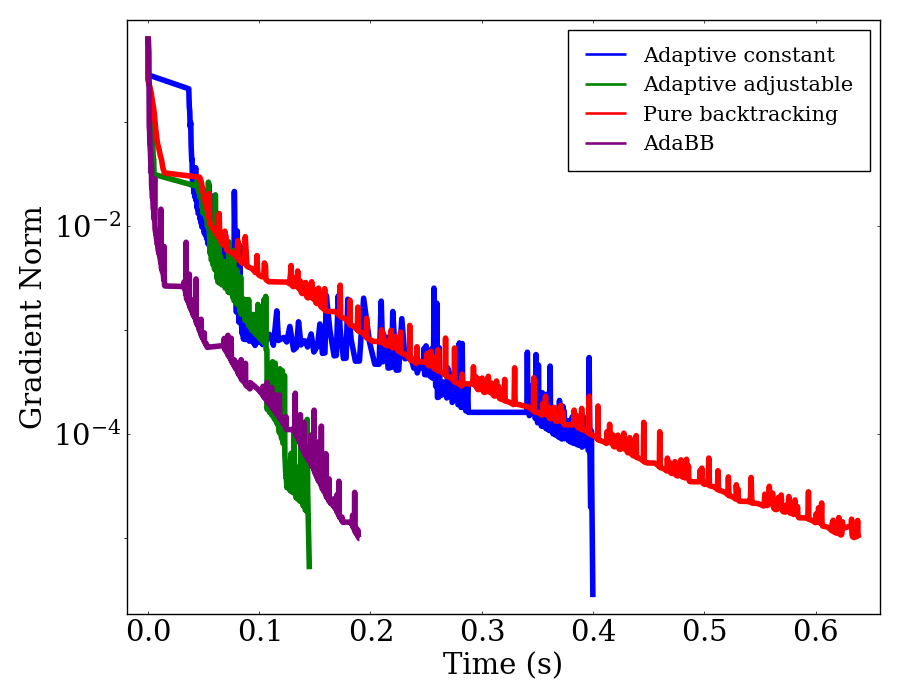


🎉 All plots saved as EPS in: /content/output


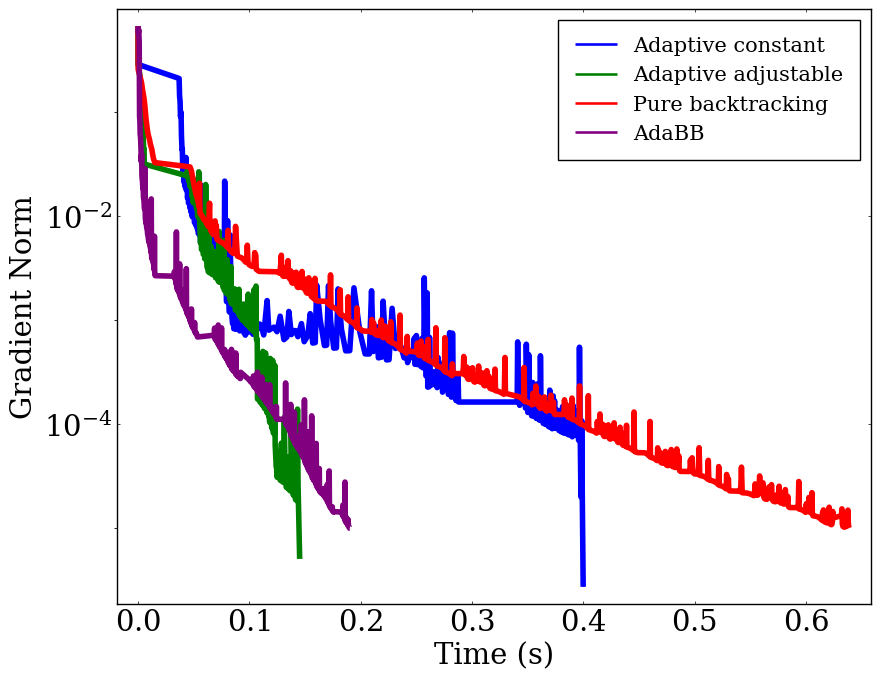

In [13]:
# Ensure all necessary packages are loaded
using MAT
using Plots
using PyPlot
using Plots.Measures

# ⚠️ Use PyPlot backend — works reliably in Colab and supports EPS
using PyPlot
pyplot()

output_dir = "/content/output"
mkpath(output_dir)

# --- LOAD DATA ONCE ---
our = matread(joinpath(output_dir, "results_FW_OUR.mat"))
our5 = matread(joinpath(output_dir, "results_FW_OUR_5.mat"))
ped = matread(joinpath(output_dir, "results_FW_Pedregosa.mat"))
ada = matread(joinpath(output_dir, "results_adabb.mat"))

# --- PRINT SUMMARY TABLE ---
println("\n# Summary of Results:\n")
println("Method               Iterations    Time (s)   Objective     Gradient Norm")
println("───────────────────  ──────────  ──────────  ───────────  ───────────")
iter_our = length(our["values"]) - 1
time_our = round(sum(our["times"]), digits=2)
obj_our  = round(our["values"][end], digits=4)
gap_our  = round(our["gaps"][end], digits=4)
println(rpad("Adaptive constant", 20), lpad(iter_our, 11), "  ", lpad(time_our, 10), "  ", lpad(obj_our, 11), "  ", lpad(gap_our, 11))
iter_our5 = length(our5["values"]) - 1
time_our5 = round(sum(our5["times"]), digits=2)
obj_our5  = round(our5["values"][end], digits=4)
gap_our5  = round(our5["gaps"][end], digits=4)
println(rpad("Adaptive adjustable", 20), lpad(iter_our5, 11), "  ", lpad(time_our5, 10), "  ", lpad(obj_our5, 11), "  ", lpad(gap_our5, 11))
iter_ped = length(ped["values"]) - 1
time_ped = round(sum(ped["times"]), digits=2)
obj_ped  = round(ped["values"][end], digits=4)
gap_ped  = round(ped["gaps"][end], digits=4)
println(rpad("Pure backtracking", 20), lpad(iter_ped, 11), "  ", lpad(time_ped, 10), "  ", lpad(obj_ped, 11), "  ", lpad(gap_ped, 11))
iter_ada = length(ada["values"]) - 1
time_ada = round(sum(ada["times"]), digits=2)
obj_ada  = round(ada["values"][end], digits=4)
gap_ada  = round(ada["gaps"][end], digits=4)
println(rpad("AdaBB", 20), lpad(iter_ada, 11), "  ", lpad(time_ada, 10), "  ", lpad(obj_ada, 11), "  ", lpad(gap_ada, 11))
println("\nAll computations and plotting complete. Check $output_dir for results.")

#________________________ PLOTTING FUNCTION ________________________#
function create_and_save_plots()
    # --- PREPARE CUMULATIVE TIMES ---
    our_cum_times = [0.0; cumsum(our["times"][1:end-1])]
    our5_cum_times = [0.0; cumsum(our5["times"][1:end-1])]
    ped_cum_times = [0.0; cumsum(ped["times"][1:end-1])]
    ada_cum_times = [0.0; cumsum(ada["times"][1:end-1])]

    # --- STYLE DICTIONARY ---
    style = Dict(
        :titlefont => (21, "serif"),
        :guidefont => (21, "serif"),
        :tickfont => (21, "serif"),
        :legendfont => (15, "serif"),
        :grid => false,
        :framestyle => :box,
        :margin => 5mm,
        :size => (900, 700),
        :linewidth => 2
    )

    # --- PLOT 1: Lipschitz Constants (AdaBB excluded — no L_ks) ---
    p1 = Plots.plot()
    Plots.plot!(p1, ped["L_ks"],
                label=false,
                color=:red,
                seriestype=:scatter,
                markersize=8,
                marker=:star5,
                markerstrokewidth=0)
    Plots.plot!(p1, our["L_ks"],
                label="Adaptive constant",
                color=:blue,
                seriestype=:scatter,
                markersize=0.1,
                marker=:rtriangle,
                markerstrokewidth=0)
    Plots.plot!(p1, our5["L_ks"],
                label="Adaptive adjustable",
                color=:green,
                seriestype=:scatter,
                markersize=0.1,
                marker=:circle,
                markerstrokewidth=0)
    Plots.plot!(p1, ped["L_ks"],
                label="Pure backtracking",
                color=:red,
                seriestype=:scatter,
                markersize=5,
                marker=:star5,
                markerstrokewidth=0)
    Plots.plot!(p1, our["L_ks"],
                label=false,
                color=:blue,
                seriestype=:scatter,
                markersize=5,
                marker=:rtriangle,
                markerstrokewidth=0)
    Plots.plot!(p1, our5["L_ks"],
                label=false,
                color=:green,
                seriestype=:scatter,
                markersize=5,
                marker=:circle,
                markerstrokewidth=0)
    Plots.plot!(p1,
            xlabel="Iteration",
            ylabel="Local Lipschitz Estimate";
            style...)

    Plots.savefig(p1, joinpath(output_dir, "R_Regression_a1a_L.eps"))
    println("✅ Saved: R_Regression_a1a_L.eps")
    display(p1)

    # --- PLOT 2: Dual Gap vs Iteration ---
    p2 = Plots.plot(our["gaps"],
                    label="Adaptive constant",
                    color=:blue,
                    markerstrokecolor=:blue,
                    markersize=7,
                    yscale=:log10,
                    xlabel="Iteration",
                    ylabel="Gradient Norm";
                    style...)
    Plots.plot!(p2, our["gaps"],
                label=false,
                color=:blue,
                markerstrokecolor=:blue,
                linewidth=4,
                markersize=7)
    Plots.plot!(p2, our5["gaps"],
                    label="Adaptive adjustable",
                    color=:green,
                    markerstrokecolor=:green,
                    linewidth=4,
                    markersize=7)
    Plots.plot!(p2, ped["gaps"],
                    label="Pure backtracking",
                    color=:red,
                    markerstrokecolor=:red,
                    linewidth=4,
                    markersize=7)
    Plots.plot!(p2, ada["gaps"],
                    label="AdaBB",
                    color=:purple,
                    markerstrokecolor=:purple,
                    linewidth=4,
                    markersize=7)

    Plots.savefig(p2, joinpath(output_dir, "R_Regression_a1a_Gap.eps"))
    println("✅ Saved: R_Regression_a1a_Gap.eps")
    display(p2)

    # --- PLOT 3: Dual Gap vs Time ---
    p3 = Plots.plot(our_cum_times[1:end-1], our["gaps"],
                    label="Adaptive constant",
                    color=:blue,
                    markerstrokecolor=:blue,
                    yscale=:log10,
                    xlabel="Time (s)",
                    ylabel="Gradient Norm",
                    markersize=7;
                    style...)
    Plots.plot!(p3, our_cum_times[1:end-1], our["gaps"],
                label=false,
                color=:blue,
                markerstrokecolor=:blue,
                linewidth=4,
                markersize=7)
    Plots.plot!(p3, our5_cum_times[1:end-1], our5["gaps"],
                    label="Adaptive adjustable",
                    color=:green,
                    markerstrokecolor=:green,
                    linewidth=4,
                    markersize=7)
    Plots.plot!(p3, ped_cum_times[1:end-1], ped["gaps"],
                    label="Pure backtracking",
                    color=:red,
                    markerstrokecolor=:red,
                    linewidth=4,
                    markersize=7)
    Plots.plot!(p3, ada_cum_times[1:end-1], ada["gaps"],
                    label="AdaBB",
                    color=:purple,
                    markerstrokecolor=:purple,
                    linewidth=4,
                    markersize=7)

    Plots.savefig(p3, joinpath(output_dir, "R_Regression_a1a_Gap_vs_time.eps"))
    println("✅ Saved: R_Regression_a1a_Gap_vs_time.eps")
    display(p3)

    println("\n🎉 All plots saved as EPS in: $output_dir")
end

# --- RUN PLOTTING ---
create_and_save_plots()

In [14]:
# Step 1: Zip the correct output folder
import Pkg; Pkg.add("PyCall")
try
    run(`zip -r /content/output.zip /content/output`)
    println("Zipping successful!")
catch e
    println("Error during zipping: ", e)
end

# Step 2: Prepare to download the file
using PyCall

# Import the Python module *before* the try...catch block
@pyimport google.colab.files as colab_files

# Step 3: Trigger the download
try
    println("Preparing to download...")
    println("Please check your browser to confirm the download.")
    # Download the correctly named zip file
    colab_files.download("/content/output.zip")
catch e
    println("Error during download: ", e)
    println("Please ensure you are running this in a Google Colab environment.")
end

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


updating: content/output/ (stored 0%)
updating: content/output/results_FW_OUR.mat (deflated 42%)
updating: content/output/results_FW_OUR_5.mat (deflated 45%)
updating: content/output/results_adabb.mat (deflated 31%)
updating: content/output/R_Regression_a1a_Gap_vs_time.eps (deflated 64%)
updating: content/output/R_Regression_a1a_Gap.eps (deflated 66%)
updating: content/output/results_FW_Pedregosa.mat (deflated 38%)
updating: content/output/R_Regression_a1a_L.eps (deflated 68%)
Zipping successful!
Preparing to download...
Please check your browser to confirm the download.
Error during download: PyError ($(Expr(:escape, :(ccall(#= /root/.julia/packages/PyCall/1gn3u/src/pyfncall.jl:43 =# @pysym(:PyObject_Call), PyPtr, (PyPtr, PyPtr, PyPtr), o, pyargsptr, kw))))) <class 'AttributeError'>
AttributeError("'NoneType' object has no attribute 'kernel'")
  File "/usr/local/lib/python3.12/dist-packages/google/colab/files.py", line 232, in download
    comm_manager = _IPython.get_ipython().kernel.